**Машинное обучение в экономике**

**Консультация. Генерация данных**

Установка библиотек

In [1]:
# !python.exe -m pip install --upgrade pip
# !pip install numpy
# !pip install pandas
# !pip install scikit-learn
# !pip install openpyxl
# !pip install doubleml

In [2]:
# Подключим необходимые библиотеки
import numpy as np
import pandas as pd
import scipy as scipy
from copy import deepcopy
import math
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from scipy.stats import t, chi2, f, norm, poisson, binom, uniform, expon, logistic
import seaborn

try:
    import networkx as nx
except ModuleNotFoundError:
    nx = None

**Описание сюжета** 😸

**Целевая переменная** - месячные траты клиента в сервисе доставки $\text{MonthlySpending}_{i}$.

**Переменная воздействия** - факт оформления премиум-подписки $\text{PremiumSubscription}_{i}$ (1 - оформил, 0 - не оформил).

**Инструментальная переменная** - факт случайного показа баннера на бесплатный пробный период подписки $\text{FreeTrialBanner}_{i}$ (1 - баннер показали, 0 - баннер не показали).

**Контрольные переменные**:

*   $\text{Income}_{i}$ - доход клиента.
*   $\text{Age}_{i}$ - возраст клиента.
*   $\text{UrbanArea}_{i}$ - факт проживания в городе (1 - живет в городе, 0 - живет не в городе).
*   $\text{RemoteWork}_{i}$ - факт удаленной работы (1 - работает удаленно, 0 - не работает удаленно).
*   $\text{FamilySize}_{i}$ - размер семьи.

**Ненаблюдаемые переменные, порождающие эндогенность**:

*  $\text{OnlinePreference}_{i}$ - склонность клиента к использованию онлайн-сервисов, влияющая и на вероятность оформления подписки, и на траты в сервисе доставки.

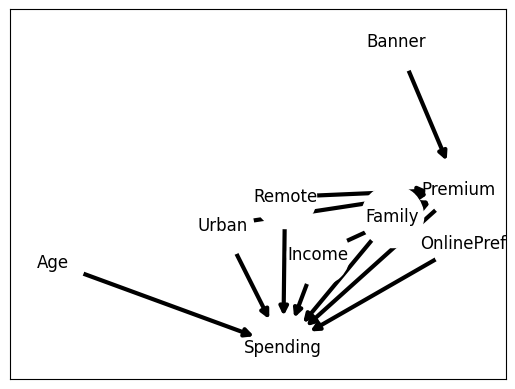

In [3]:
# Визуализируем предполагаемые связи

if nx is not None:
    # Стиль отображения графика
    nx_options = {
        'node_color': 'white',
        'node_size': 2000,
        'width': 3,
        'arrowstyle': '-|>',
        'arrowsize': 12,
    }

    # Связи
    edges = [
        ('Premium', 'Spending'),         # (откуда стрелочка, куда стрелочка)
        ('Income', 'Spending'),
        ('Age', 'Spending'),
        ('Urban', 'Spending'),
        ('Remote', 'Spending'),
        ('Family', 'Spending'),
        ('OnlinePref', 'Spending'),
        ('OnlinePref', 'Premium'),
        ('Income', 'Premium'),
        ('Urban', 'Premium'),
        ('Remote', 'Premium'),
        ('Family', 'Premium'),
        ('Banner', 'Premium'),

    ]

    # Инициализируем граф
    G = nx.DiGraph(directed = True)
    G.add_edges_from(edges)

    # Отображаем граф
    np.random.seed(8)
    nx.draw_networkx(G, arrows = True, **nx_options)
else:
    print('Для визуализации графа установите библиотеку networkx.')

**Генерация контрольных переменных** 😸

Будем генерировать доход клиента $\text{Income}_{i}$ взяв за основу нормальное распределение для логарифма дохода:

$$\ln(\text{Income}_{i}) \sim \text{N}\left(10.98, 0.5^2\right)$$

Техническое примечание ⚡

Функция `scipy.stats.norm.rvs()` позволяет сгенерировать `size` независимых случайных величин из нормального распределения с математическим ожиданием `loc` и стандартным отклонением (квадратный корень из дисперсии) `scale`.

Если затем применить к полученным значениям `np.exp()`, то получится логнормальное распределение.

In [4]:
# Для воспроизводимости
np.random.seed(123)

In [5]:
# Число наблюдений
n = 100000

In [6]:
# Предположим, что логарифм дохода схож с нормальным
income = np.exp(norm.rvs(size = n, loc = 10.98, scale = 0.5))

# Посмотрим на несколько первых значений
print(income[0:10])

[ 34104.50269341  96632.7242602   67608.51725738  27635.39459673
  43945.25237761 134016.50842529  17442.41876157  47360.49330499
 110521.80705163  38048.98923715]


<Axes: ylabel='Density'>

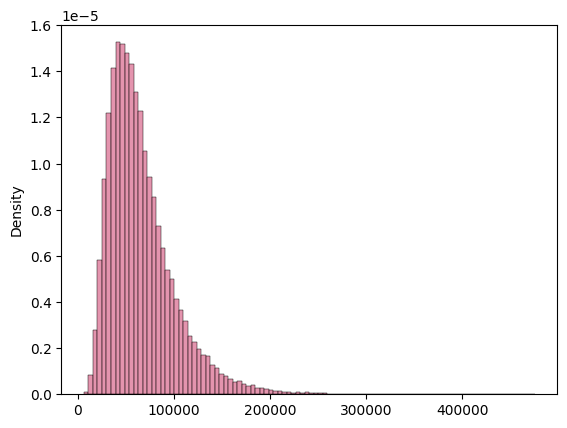

In [7]:
# Посмотрим на распределение
seaborn.histplot(income,                     # данные
                 stat = 'density',           # тип гистограммы
                 color = "palevioletred",    # цвет гистограммы
                 label = "histogram",        # наименование гистограммы
                 bins = 100)                 # число столбиков в Гистограмме

Будем генерировать возраст $\text{Age}_{i}$ взяв за основу нормальное распределение $\text{N}\left(35, 10^2\right)$.

Техническое примечание ⚡

Функция `scipy.stats.norm.rvs()` позволяет сгенерировать `size` независимых случайных величин из нормального распределения с математическим ожиданием `loc` и стандартным отклонением (квадратный корень из дисперсии) `scale`.

In [8]:
# Предположим, что распределение возраста схоже с нормальным
age = norm.rvs(size = n, loc = 35, scale = 10)

# Для красоты ограничим минимальные и максимальные значения
age[age >= 65] = 65
age[age <= 18] = 18

# Также, для удобства введем округление
age = np.round(age)

# Посмотрим на несколько первых значений
print(age[0:10])

[42. 38. 24. 18. 29. 45. 34. 44. 43. 28.]


<Axes: ylabel='Density'>

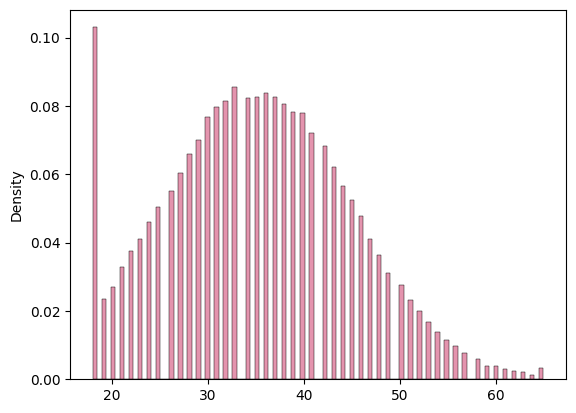

In [9]:
# Посмотрим на распределение
seaborn.histplot(age,                        # данные
                 stat = 'density',           # тип гистограммы
                 color = "palevioletred",    # цвет гистограммы
                 label = "histogram",        # наименование гистограммы
                 bins = 100)                 # число столбиков в Гистограмме

Поскольку $\text{UrbanArea}_{i}$ является бинарной переменной, принимающей значения $0$ и $1$, то она имеет распределение Бернулли $\text{UrbanArea}_{i}\sim\text{Ber}(p)$. Предположим, что в городе живут $70\%$ клиентов, откуда $p=0.7$.

Техническое примечание ⚡

Функция `np.random.binomial()` позволяет сгенерировать `size` независимых случайных величин из биномиального распределения с параметрами `n` и `p`. Напомним, что распределение Бернулли является частным случаем биномиального распределения при `n = 1`.

In [10]:
# Сгенерируем переменную на факт проживания в городе
urban_area = np.random.binomial(n = 1, p = 0.7, size = n)

# Посмотрим на первые несколько значение
print(urban_area[0:10])

[1 1 1 1 1 0 1 1 1 1]


In [11]:
# Доля клиентов, проживающих в городе
print(np.mean(urban_area))

0.69973


По аналогии сгенерируем переменную на удаленную работу, предполагая $\text{RemoteWork}_{i}\sim\text{Ber}\left(0.2\right)$.

In [12]:
# Сгенерируем переменную на удаленную работу
remote_work = np.random.binomial(n = 1, p = 0.2, size = n)

# Доля клиентов, работающих удаленно
print(np.mean(remote_work))

0.20091


Размер семьи $\text{FamilySize}_{i}$ будем генерировать как дискретную случайную величину, принимающую значения от $1$ до $5$, где значение $5$ означает «$5$ и более».

Техническое примечание ⚡

Функция `np.random.choice()` позволяет сгенерировать `size` независимых случайных величин, принимающих заданные значения с заранее определенными вероятностями.

In [13]:
# Сгенерируем размер семьи
family_size = np.random.choice(a = [1, 2, 3, 4, 5],
                               size = n,
                               p = [0.20, 0.35, 0.25, 0.15, 0.05])

# Посмотрим на несколько первых значений
print(family_size[0:10])

[2 2 3 3 1 2 2 4 2 2]


In [14]:
# Распределение размеров семьи
print(pd.Series(family_size).value_counts(normalize = True).sort_index())

1    0.20254
2    0.35157
3    0.24886
4    0.14896
5    0.04807
Name: proportion, dtype: float64


Для простоты мы сгенерировали контрольные переменные как независимые. Однако, при генерации можно также предполагать наличие связи между переменными. Для этого, например, можно воспользоваться [копулами](https://pypi.org/project/copulas/).

**Генерация ненаблюдаемой переменной, порождающей эндогенность** 😸

Сгенерируем склонность к онлайн-заказам $\text{OnlinePreferenceRaw}_{i}$ взяв за основу нормальное распределение $\text{N}(0, 1)$.

Затем превратим ее в величину $\text{OnlinePreference}_{i}$ с помощью логистической функции распределения.

Эта переменная будет играть роль ненаблюдаемой, отсутствие в данных которой и приводит к проблеме эндогенности.

Техническое примечание ⚡

Функция `scipy.stats.logistic.cdf()` позволяет применить функцию распределения стандартного логистического распределения к уже сгенерированным значениям.

In [15]:
# Генерируем склонность к онлайн-заказам
online_preference_raw = norm.rvs(size = n, loc = 0, scale = 1)
online_preference = logistic.cdf(online_preference_raw)

# Посмотрим на несколько первых значений
print(online_preference[0:10])

[0.6097816  0.50044921 0.65828579 0.29325845 0.52230037 0.30511483
 0.17271063 0.10983717 0.51560785 0.58278223]


<Axes: ylabel='Density'>

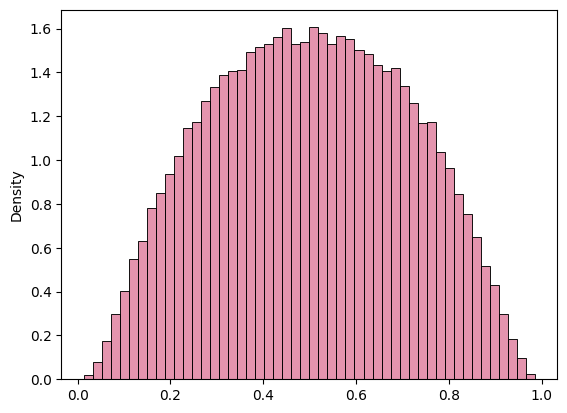

In [16]:
# Посмотрим на распределение склонности к онлайн-заказам
seaborn.histplot(online_preference,          # данные
                 stat  = 'density',          # тип гистограммы
                 color = "palevioletred",    # цвет гистограммы
                 label = "histogram",        # наименование гистограммы
                 bins  = 50)                 # число столбиков в Гистограмме

**Генерация инструментальной переменной** 😸

Поскольку баннер на бесплатный пробный период показывается случайно, удобно предположить, что инструментальная переменная имеет распределение Бернулли:

$$\text{FreeTrialBanner}_{i}\sim\text{Ber}(0.3)$$

Такой способ генерации сразу отражает случайный характер инструмента.

In [17]:
# Сгенерируем случайный показ баннера на пробный период
free_trial_banner = np.random.binomial(n = 1, p = 0.3, size = n)

# Посмотрим на несколько сгенерированных значений
print(free_trial_banner[0:10])

[1 0 0 0 1 0 0 0 0 1]


In [18]:
# Доля клиентов, которым показали баннер
print(np.mean(free_trial_banner))

0.29942


**Генерация переменной воздействия** 😸

Удобно предположить, что условные вероятности переменной воздействия зависят от контрольных переменных, инструментальной переменной и ненаблюдаемой переменной.

$$P(\text{PremiumSubscription}_{i} = 1|\text{Income}_{i}, \text{UrbanArea}_{i}, \text{RemoteWork}_{i}, \text{FamilySize}_{i}, \text{OnlinePreference}_{i}, \text{FreeTrialBanner}_{i}) = \\ = F_{\text{Logistic}}\left(-6 + 2.8\times\text{OnlinePreference}_{i} + 0.20\times\ln(\text{Income}_{i}) + 0.35\times\text{UrbanArea}_{i} + 0.25\times\text{RemoteWork}_{i} + 0.15\times\text{FamilySize}_{i} + 1.3\times\text{FreeTrialBanner}_{i}\right)$$

Где $F_{\text{Logistic}}$ - функция распределения стандартного логистического распределения.

Для краткости введем обозначение для условной вероятности оформления подписки при конкретном значении баннера:

$$p_{k}^{\text{FreeTrialBanner}_{i}} = P(\text{PremiumSubscription}_{i} = 1|\text{Income}_{i}, \text{UrbanArea}_{i}, \text{RemoteWork}_{i}, \text{FamilySize}_{i}, \text{OnlinePreference}_{i}, \text{FreeTrialBanner}_{i} = k)\text{, где }k\in\{0,1\}$$

Для того, чтобы впоследствии анализировать локальные средние эффекты воздействия $\text{LATE}$, необходимо различать величину переменной воздействия $\text{PremiumSubscription}_{i}$ в зависимости от значения инструмента $\text{FreeTrialBanner}_{i}$. Для этого рассмотрим ни от чего не зависящую равномерную случайную величину $U_{i}\sim U(0,1)$ и введем гипотетические переменные:

$$\text{Premium}_{1i} = I(p_{1}^{\text{FreeTrialBanner}_{i}}\geq U_{i})$$

$$\text{Premium}_{0i} = I(p_{0}^{\text{FreeTrialBanner}_{i}}\geq U_{i})$$


$$I(\text{условие}) = \begin{cases}1\text{, если условие выполнено}\\0\text{, в противном случае}\end{cases}$$

Переменные $\text{Premium}_{1i}$ и $\text{Premium}_{0i}$ отражают потенциальный факт оформления подписки в зависимости от показа баннера.

In [19]:
# Равномерные случайные величины
u = uniform.rvs(size = n)

In [20]:
# Сгенерируем часть индекса, не зависящую от показа баннера
premium_index = -6.0 + 2.8 * online_preference + 0.20 * np.log(income) + 0.35 * urban_area + 0.25 * remote_work + 0.15 * family_size

In [21]:
# Симулируем оформление подписки клиентами в случае,
# когда им показали баннер на пробный период
free_trial_banner1 = 1
premium1_index     = premium_index + 1.3 * free_trial_banner1
premium1_prob      = logistic.cdf(premium1_index)
premium1           = (premium1_prob >= u).astype(int)

# Доля клиентов с подпиской в случае, когда всем показали баннер
np.mean(premium1)

np.float64(0.40386)

In [22]:
# Симулируем оформление подписки клиентами в случае,
# когда им не показали баннер на пробный период
free_trial_banner0 = 0
premium0_index     = premium_index + 1.3 * free_trial_banner0
premium0_prob      = logistic.cdf(premium0_index, scale = 1)
premium0           = (premium0_prob >= u).astype(int)

# Доля клиентов с подпиской в случае, когда никому не показали баннер
np.mean(premium0)

np.float64(0.16794)

Индивидов можно разделить на $4$ группы:


*   **Always takers** - те, у кого $\text{Premium}_{0i}=\text{Premium}_{1i}=1$: оформляют подписку независимо от показа баннера.
*   **Never takers**- те, у кого $\text{Premium}_{0i}=\text{Premium}_{1i}=0$: не оформляют подписку независимо от показа баннера.
*   **Compliers** - те, у кого $\text{Premium}_{1i}=1$ и $\text{Premium}_{0i}=0$, то есть $\text{Premium}_{1i} > \text{Premium}_{0i}$: оформляют подписку лишь в случае, если им показали баннер.
*   **Deniers** - те, у кого $\text{Premium}_{1i}=0$ и $\text{Premium}_{0i}=1$, то есть $\text{Premium}_{1i} < \text{Premium}_{0i}$: оформляют подписку лишь в случае, если им не показали баннер.

Для соблюдения предпосылок используемых методов важно отсутствие Deniers, что гарантируется используемым процессом генерации данных.

In [23]:
# Рассмотрим различные группы индивидов
ind_type = np.empty(n, dtype = 'U25')
ind_type[(premium1 == 1) & (premium0 == 1)] = 'Always taker'
ind_type[(premium1 == 0) & (premium0 == 0)] = 'Never taker'
ind_type[premium1 > premium0]               = 'Complier'
ind_type[premium1 < premium0]               = 'Denier'

# Посмотрим на распределение индивидов разного типа
print(pd.Series(ind_type).value_counts())

Never taker     59614
Complier        23592
Always taker    16794
Name: count, dtype: int64


In [24]:
# Сравним оформление подписки для одного и того же клиента в случаях,
# когда ему не показали баннер и когда баннер ему показали
print(pd.DataFrame(data    = np.array([premium0, premium1, ind_type]).transpose(),
                   columns = ['premium0', 'premium1', 'Тип индивида']))

      premium0 premium1  Тип индивида
0            0        0   Never taker
1            1        1  Always taker
2            0        0   Never taker
3            0        0   Never taker
4            0        0   Never taker
...        ...      ...           ...
99995        0        0   Never taker
99996        0        1      Complier
99997        0        0   Never taker
99998        0        0   Never taker
99999        1        1  Always taker

[100000 rows x 3 columns]


Наблюдаемый (в данных) факт оформления подписки можно выразить как:

$$\text{PremiumSubscription}_{i} = \begin{cases}\text{Premium}_{1i}\text{, если }\text{FreeTrialBanner}_{i} = 1\\ \text{Premium}_{0i}\text{, если }\text{FreeTrialBanner}_{i} = 0\end{cases} = \\ = \text{Premium}_{1i}\times\text{FreeTrialBanner}_{i} + \text{Premium}_{0i}\times\left(1 - \text{FreeTrialBanner}_{i}\right)$$

In [25]:
# Факт наличия у клиента премиум-подписки
premium_subscription = premium1 * free_trial_banner + premium0 * (1 - free_trial_banner)

# Доля клиентов с премиум-подпиской
print(np.mean(premium_subscription))

0.23862


**Важно**

*   При слабой корреляции между $\text{PremiumSubscription}_{i}$ и $\text{OnlinePreference}_{i}$ проблема эндогенности окажется несущественной, а при слишком большой скорректировать эндогенность окажется чрезвычайно сложно.
*   При слабой корреляции между $\text{PremiumSubscription}_{i}$ и $\text{FreeTrialBanner}_{i}$ инструмент не будет релевантным и поэтому не позволит скорректировать эндогенность.

Таким образом, полезно отдельно проверить соответствующие корреляции.

In [26]:
# Рассмотрим корреляции
print(pd.DataFrame(data    = [np.corrcoef(premium_subscription, online_preference)[0, 1],
                              np.corrcoef(premium_subscription, free_trial_banner)[0, 1]],
                   index   = ['Corr(premium_subscription, online_preference)',
                              'Corr(premium_subscription, free_trial_banner)'],
                   columns = ['Оценка']))

                                                 Оценка
Corr(premium_subscription, online_preference)  0.213502
Corr(premium_subscription, free_trial_banner)  0.253778


**Генерация целевой переменной** 😸

Сформируем представления о формировании потенциальных месячных трат в зависимости от наличия премиум-подписки.

**Основная идея**- премиум-подписка повышает месячные траты клиента, а склонность к онлайн-заказам влияет на траты и без подписки.

Уравнение месячных трат при отсутствии премиум-подписки:

$$\text{MonthlySpending}_{0i} = \underbrace{\underbrace{5000\times\text{OnlinePreference}_{i}}_{g_{0}^{\text{unobs}}} + \underbrace{-23000 + 2500\times\ln(\text{Income}_{i}) + 1200\times\text{UrbanArea}_{i} + 900\times\text{RemoteWork}_{i} + 1000\times\text{FamilySize}_{i} - 25\times\text{Age}_{i}}_{g_{0}^{\text{obs}}}}_{g_{0}} + \varepsilon_{0i}\text{, где }\varepsilon_{0i}\sim \left(1500\times t(15)\right)$$

Уравнение месячных трат при наличии премиум-подписки:

$$\text{MonthlySpending}_{1i} = \underbrace{\underbrace{6000\times\text{OnlinePreference}_{i}}_{g_{1}^{\text{unobs}}} + \underbrace{-21500 + 2500\times\ln(\text{Income}_{i}) + 1200\times\text{UrbanArea}_{i} + 1300\times\text{RemoteWork}_{i} + 1200\times\text{FamilySize}_{i} - 25\times\text{Age}_{i}}_{g_{1}^{\text{obs}}}}_{g_{1}} + \varepsilon_{1i}\text{, где }\varepsilon_{1i}\sim \left(\text{EXP}(1500) - 1500\right)$$

Месячные траты не могут быть отрицательными, поэтому после генерации ограничим их снизу нулем.

Наблюдаемые месячные траты:

$$\text{MonthlySpending}_{i} = \begin{cases}\text{MonthlySpending}_{1i}\text{, если }\text{PremiumSubscription}_{i}=1\\ \text{MonthlySpending}_{0i}\text{, если }\text{PremiumSubscription}_{i}=0\end{cases} = \\ =\text{MonthlySpending}_{1i}\times\text{PremiumSubscription}_{i} + \text{MonthlySpending}_{0i}\times\left(1-\text{PremiumSubscription}_{i}\right)$$

In [27]:
# Случайные ошибки
error0 = t.rvs(size = n, df = 15) * 1500
error1 = expon.rvs(size = n, scale = 1500) - 1500

# Функция от контрольных переменных
  # когда у клиента нет премиум-подписки
g0_obs   = -23000 + 2500 * np.log(income) + 1200 * urban_area + 900 * remote_work + 1000 * family_size - 25 * age
g0_unobs = 5000 * online_preference
g0       = g0_obs + g0_unobs
  # когда у клиента есть премиум-подписка
g1_obs   = -21500 + 2500 * np.log(income) + 1200 * urban_area + 1300 * remote_work + 1200 * family_size - 25 * age
g1_unobs = 6000 * online_preference
g1       = g1_obs + g1_unobs

# Месячные траты в зависимости от наличия премиум-подписки
monthly_spending0 = g0 + error0
monthly_spending1 = g1 + error1
monthly_spending0[monthly_spending0 <= 0] = 0
monthly_spending1[monthly_spending1 <= 0] = 0

# Наблюдаемые месячные траты
monthly_spending = monthly_spending1 * premium_subscription + monthly_spending0 * (1 - premium_subscription)

Во избежание чрезвычайно точных или крайне неточных оценок, желательно, чтобы при каждом $j\in\{0, 1\}$ дисперсии $\varepsilon_{ji}$, $g_{j}$, $g_{j}^{\text{obs}}$ и  $g_{j}^{\text{unobs}}$ различались не более, чем в $5$ раз.

In [28]:
# Приблизительно оценим адекватность дисперсий
print(pd.DataFrame(data    = [np.var(error0),   np.var(g0),
                              np.var(g0_obs),   np.var(g0_unobs),
                              np.var(error1),   np.var(g1),
                              np.var(g1_obs),   np.var(g1_unobs)],
                   index   = ['Var(eps0)',     'Var(g0)',
                              'Var(g0_obs)',   'Var(g0_unobs)',
                              'Var(eps1)',     'Var(g1)',
                              'Var(g1_obs)',   'Var(g1_unobs)'],
                   columns = ['Оценка']))

                     Оценка
Var(eps0)      2.592576e+06
Var(g0)        4.413182e+06
Var(g0_obs)    3.302431e+06
Var(g0_unobs)  1.093949e+06
Var(eps1)      2.240886e+06
Var(g1)        5.586905e+06
Var(g1_obs)    3.990084e+06
Var(g1_unobs)  1.575286e+06


**Объединение данных** 😸

In [29]:
# Аггрегируем данные в датафрейм
df = pd.DataFrame({
    "monthly_spending": monthly_spending,
    "premium_subscription": premium_subscription,
    "income": income,
    "age": age,
    "urban_area": urban_area,
    "family_size": family_size,
    "remote_work": remote_work,
    "free_trial_banner": free_trial_banner
})
df = df.loc[0:n, :]

# Посмотрим на симулированные данные
df.head(10).style.format(precision = 2)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,remote_work,free_trial_banner
0,6226.36,0,34104.50,42.00,1,2,0,1
1,14105.20,1,96632.72,38.00,1,2,0,0
2,14062.54,0,67608.52,24.00,1,3,1,0
3,7749.89,0,27635.39,18.00,1,3,0,0
4,7654.27,0,43945.25,29.00,1,1,0,1
5,11828.67,0,134016.51,45.00,0,2,0,0
6,3930.94,0,17442.42,34.00,1,2,0,0
7,9973.59,0,47360.49,44.00,1,4,1,0
8,9400.56,0,110521.81,43.00,1,2,0,0
9,9595.01,0,38048.99,28.00,1,2,0,1


**Оценивание эффектов воздействия с помощью потенциальных исходов** 🐱

Эффект воздействия:

$$\text{TE}_{i} = \text{MonthlySpending}_{1i} - \text{MonthlySpending}_{0i}$$

In [30]:
# Настоящие эффекты воздействия (не наблюдаются в данных)
TE = monthly_spending1 - monthly_spending0
print(TE[0:10])

[3533.26424036 4883.77777272 3097.86772947 1716.99977303 3194.55598078
 -927.30434117 1392.99953383 4606.27870546 4457.00529914 2687.54633571]


Средний эффект воздействия:

$$\text{ATE} = \text{E}\left(\text{MonthlySpending}_{1i} - \text{MonthlySpending}_{0i}\right)$$

Если бы у нас были данные о $\text{MonthlySpending}_{1i}$ и $\text{MonthlySpending}_{0i}$, то мы могли бы очень точно оценить $\text{ATE}$ как:

$$\widehat{\text{ATE}} = \frac{1}{n}\sum\limits_{i=1}^{n}\text{MonthlySpending}_{1i} - \text{MonthlySpending}_{0i}$$

In [31]:
# Точное приближение среднего эффекта воздействия, то есть
# с помощью оценки, недоступной с помощью реальных данных
ATE = np.mean(TE)
print(ATE)

2566.0847185161465


Локальный средний эффект воздействия:

$$\text{LATE} = \text{E}(\text{MonthlySpending}_{1i} - \text{MonthlySpending}_{0i} | \text{Premium}_{1i} > \text{Premium}_{0i})$$

In [32]:
# Точное приближение локального среднего эффекта воздействия, то есть
# с помощью оценки, недоступной с помощью реальных данных
LATE = np.mean(TE[ind_type == "Complier"])
print(LATE)

2617.2799899179386


Условный средний эффект воздействия:

$$\text{CATE}_{i} = \text{E}\left(\text{MonthlySpending}_{1i}|X_{i}\right) - \text{E}\left(\text{MonthlySpending}_{0i}|X_{i}\right) = g_{1}(X_{i}) - g_{0}(X_{i})$$

In [33]:
# Значения локальных средних эффектов воздействия
CATE = g1 - g0
print(CATE[0:10])

[2509.78159973 2400.44920745 3158.28579361 2393.2584455  2222.30036689
 2205.11482765 2072.71062765 2809.83717069 2415.60785356 2482.78223468]


**Оценивание ATE как разницы в средних** 🐱

Наивный подход предполагает оценивание $\text{ATE}$ как средней разницы в месячных тратах клиентов с премиум-подпиской и без нее.

$$\widehat{\text{ATE}}_{\text{naive}} = \frac{1}{n_{1}}\sum\limits_{i:\text{PremiumSubscription}_{i}=1}\text{MonthlySpending}_{1i} - \frac{1}{n_{0}}\sum\limits_{i:\text{PremiumSubscription}_{i}=0}\text{MonthlySpending}_{0i}$$

In [34]:
# Наивная оценка как разница в выборочных средних
ATE_naive = np.mean(monthly_spending[premium_subscription == 1]) - np.mean(monthly_spending[premium_subscription == 0])

# Сравнение точного приближения и наивной оценки
print(pd.DataFrame(data    = [ATE, ATE_naive],
                   index   = ['Точная оценка с помощью потенциальных исходов',
                              'Наивная оценка с помощью наблюдаемых исходов'],
                   columns = ['ATE'] ))

                                                       ATE
Точная оценка с помощью потенциальных исходов  2566.084719
Наивная оценка с помощью наблюдаемых исходов   3563.226082


**Цель** - используя ненаблюдаемые в данных потенциальные исходы оценить $\text{ATE}$ точнее, чем наивным методом, используя для этого синтез методов эконометрического анализа и машинного обучения.